In [2]:
CSV="./TAD/pred_results_25kbp_ctx512.csv"

Wrote: ./TAD/pred_vs_true.tsv
Saved figure: ./TAD/pred_vs_true_scatter.png
Pearson=0.4325  Spearman=0.4187


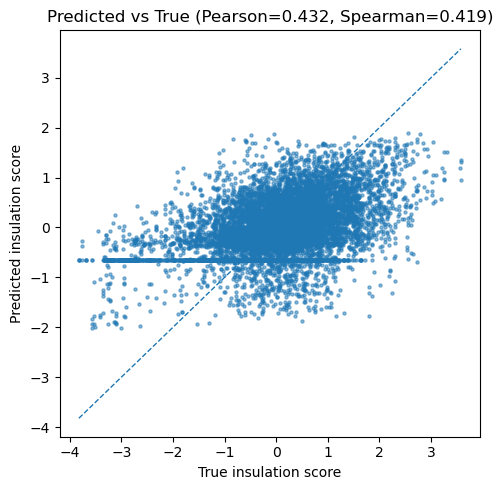

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# CSV = "pred_results.csv"   # first col = true, second = pred
OUT_TSV = "./TAD/pred_vs_true.tsv"
OUT_PNG = "./TAD/pred_vs_true_scatter.png"

# 1) read CSV with header (e.g., "TPM" etc.)
df = pd.read_csv(CSV)  # keeps header
# take first two columns explicitly
true = pd.to_numeric(df.iloc[:,0], errors="coerce")
pred = pd.to_numeric(df.iloc[:,1], errors="coerce")
mask = np.isfinite(true) & np.isfinite(pred)
true = true[mask]; pred = pred[mask]

# 2) write a clean 2-col TSV (no header)
pd.DataFrame({"true": true, "pred": pred}).to_csv(OUT_TSV, sep="\t", index=False, header=False)

# 3) correlations
pear, _ = pearsonr(true, pred)
spear, _ = spearmanr(true, pred)

# 4) scatter plot
plt.figure(figsize=(5,5))
plt.scatter(true, pred, s=5, alpha=0.5)
# y = x reference
mn, mx = float(np.min(true)), float(np.max(true))
plt.plot([mn, mx], [mn, mx], "--", lw=1)

plt.title(f"Predicted vs True (Pearson={pear:.3f}, Spearman={spear:.3f})")
plt.xlabel("True insulation score")
plt.ylabel("Predicted insulation score")
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=200)
print(f"Wrote: {OUT_TSV}\nSaved figure: {OUT_PNG}\nPearson={pear:.4f}  Spearman={spear:.4f}")

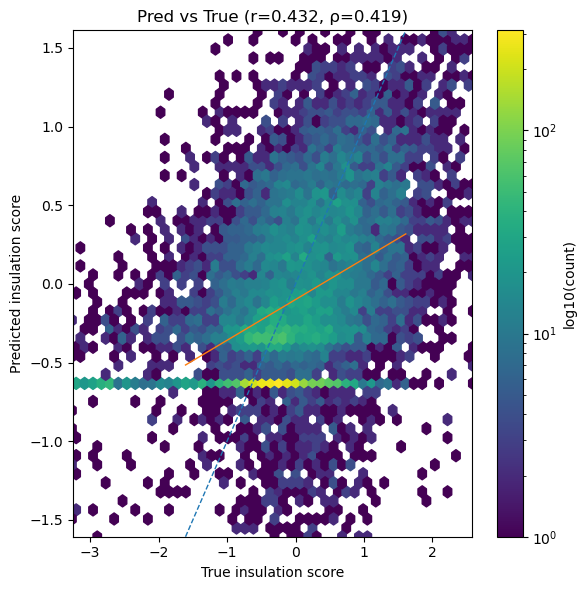

In [5]:
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, linregress

pear, _ = pearsonr(true, pred)
spear, _ = spearmanr(true, pred)
p = np.percentile(true, [0.5, 99.5]); q = np.percentile(pred, [0.5, 99.5])

plt.figure(figsize=(6,6))
hb = plt.hexbin(true, pred, gridsize=60, bins='log')
plt.colorbar(hb, label='log10(count)')

# y = x
mn, mx = max(p[0], q[0]), min(p[1], q[1])
plt.plot([mn, mx], [mn, mx], linestyle='--', linewidth=1)

# best-fit line
slope, intercept, *_ = linregress(true, pred)
xfit = np.linspace(mn, mx, 100)
plt.plot(xfit, slope*xfit + intercept, linewidth=1)

plt.xlim(p); plt.ylim(q)
plt.title(f"Pred vs True (r={pear:.3f}, ρ={spear:.3f})")
plt.xlabel("True insulation score"); plt.ylabel("Predicted insulation score")
plt.tight_layout(); plt.show()


In [6]:
# 1) Is there a spike around -0.8?
vals, cnts = np.unique(np.round(pred, 2), return_counts=True)
top = sorted(zip(cnts, vals), reverse=True)[:10]
print("Top prediction modes (count, value):", top)

# 2) Do the “flat” predictions come from certain chromosomes or token lengths?
flat_mask = (pred > -0.82) & (pred < -0.78)
print("Flat %:", flat_mask.mean())
# if you kept meta: chrom[flat_mask].value_counts() ; tok_len[flat_mask].describe()

# 3) Calibration check
print("true mean/std:", np.mean(true), np.std(true))
print("pred mean/std:", np.mean(pred), np.std(pred))


Top prediction modes (count, value): [(np.int64(2717), np.float64(-0.64)), (np.int64(137), np.float64(-0.32)), (np.int64(125), np.float64(-0.34)), (np.int64(122), np.float64(-0.35)), (np.int64(115), np.float64(-0.31)), (np.int64(115), np.float64(-0.33)), (np.int64(111), np.float64(-0.3)), (np.int64(110), np.float64(-0.36)), (np.int64(99), np.float64(-0.29)), (np.int64(88), np.float64(-0.26))]
Flat %: 0.0023224653863331843
true mean/std: 0.0028302683445837456 0.9879564234431686
pred mean/std: -0.09897249952953724 0.5913029684689802


Saved: pred_vs_true_hexbin.png, residuals_hexbin.png


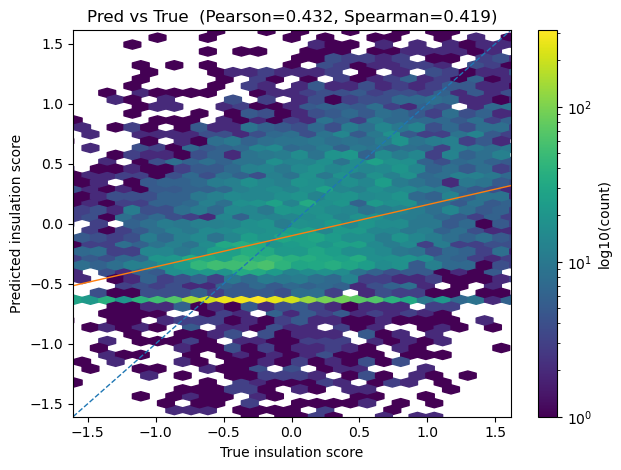

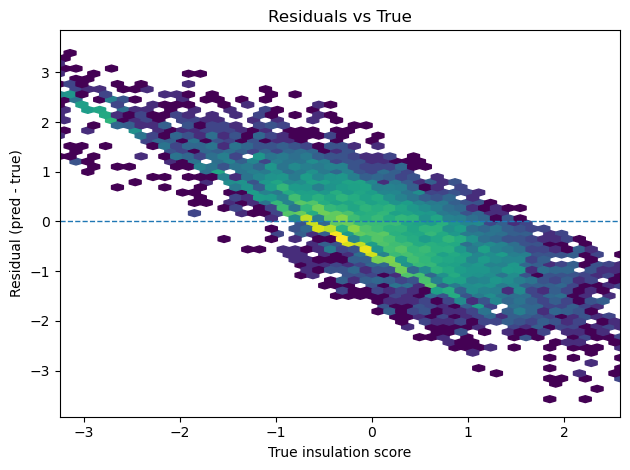

In [9]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, linregress

df = pd.read_csv(CSV)   # first col true, second pred
true = pd.to_numeric(df.iloc[:,0], errors="coerce")
pred = pd.to_numeric(df.iloc[:,1], errors="coerce")
m = np.isfinite(true) & np.isfinite(pred)
true, pred = true[m], pred[m]

# correlations
r, _ = pearsonr(true, pred)
rho, _ = spearmanr(true, pred)

# percentiles to clip axes (reduces outlier stretch)
tx = np.percentile(true, [0.5, 99.5])
px = np.percentile(pred, [0.5, 99.5])
mn, mx = max(tx[0], px[0]), min(tx[1], px[1])

# best-fit line
slope, intercept, *_ = linregress(true, pred)
xfit = np.linspace(mn, mx, 100)

# ---- density scatter (hexbin) ----
plt.figure()
hb = plt.hexbin(true, pred, gridsize=60, bins="log")
plt.colorbar(hb, label="log10(count)")
plt.plot([mn, mx], [mn, mx], "--", lw=1)                 # y=x
plt.plot(xfit, slope*xfit + intercept, lw=1)             # best-fit
plt.xlim(mn, mx); plt.ylim(mn, mx)
plt.xlabel("True insulation score")
plt.ylabel("Predicted insulation score")
plt.title(f"Pred vs True  (Pearson={r:.3f}, Spearman={rho:.3f})")
plt.tight_layout(); plt.savefig("pred_vs_true_hexbin.png", dpi=200)

# ---- residuals (shows the horizontal band clearly) ----
res = pred - true
plt.figure()
plt.hexbin(true, res, gridsize=60, bins="log")
plt.axhline(0, ls="--", lw=1)
plt.xlim(tx); plt.xlabel("True insulation score")
plt.ylabel("Residual (pred - true)")
plt.title("Residuals vs True")
plt.tight_layout(); plt.savefig("residuals_hexbin.png", dpi=200)

print("Saved: pred_vs_true_hexbin.png, residuals_hexbin.png")
